--- 
# Partie 1 – Exploration du dataset

In [6]:
# Importer les packages
import os
import shutil
import hashlib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

RAW_DIR = Path("../data/raw")
CLEANED_DIR = Path("../data/cleaned")
REPORTS_DIR = Path("../reports")

CLASSES = sorted([d.name for d in RAW_DIR.iterdir() if d.is_dir()])
print("Classes détectées :", CLASSES)

Classes détectées : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [7]:
def auditer_image(path: Path, classe: str) -> dict:
    """Extrait les métadonnées d'une image. Retourne un dict avec un flag 'corrompue' si le
    fichier ne peut pas être ouvert/lu correctement."""
    info = {
        "nom": path.name,
        "classe": classe,
        "chemin": str(path),
        "taille_octets": path.stat().st_size if path.exists() else np.nan,
        "format": np.nan,
        "mode": np.nan,
        "largeur": np.nan,
        "hauteur": np.nan,
        "nb_canaux": np.nan,
        "ecart_type_pixels": np.nan,
        "corrompue": False,
    }
    try:
        with Image.open(path) as im:
            im.verify() 
        with Image.open(path) as im:
            info["format"] = im.format
            info["mode"] = im.mode
            info["largeur"], info["hauteur"] = im.size
            arr = np.array(im.convert("RGB"))
            info["nb_canaux"] = len(im.getbands())
            info["ecart_type_pixels"] = float(arr.std())
    except Exception as e:
        info["corrompue"] = True
        info["erreur"] = str(e)
    return info


records = []
for classe in CLASSES:
    for path in sorted((RAW_DIR / classe).iterdir()):
        if path.is_file():
            records.append(auditer_image(path, classe))

audit_df = pd.DataFrame(records)
print(f"{len(audit_df)} images auditées.")
audit_df.head()


1032 images auditées.


,nom,classe,chemin,taille_octets,format,mode,largeur,hauteur,nb_canaux,ecart_type_pixels,corrompue,erreur
0,cardboard1.jpg,cardboard,..\data\raw\cardboard\cardboard1.jpg,17333,JPEG,RGB,512.0,384.0,3.0,40.586504,False,NaN
1,cardboard10.jpg,cardboard,..\data\raw\cardboard\cardboard10.jpg,21683,JPEG,RGB,512.0,384.0,3.0,42.577273,False,NaN
2,cardboard100.jpg,cardboard,..\data\raw\cardboard\cardboard100.jpg,14884,JPEG,RGB,512.0,384.0,3.0,46.121684,False,NaN
3,cardboard101.jpg,cardboard,..\data\raw\cardboard\cardboard101.jpg,14289,JPEG,RGB,512.0,384.0,3.0,72.264255,False,NaN
4,cardboard102.jpg,cardboard,..\data\raw\cardboard\cardboard102.jpg,18015,JPEG,RGB,512.0,384.0,3.0,48.389753,False,NaN


---
# Partie 2 – Détecter les images corrompues 

In [8]:
def est_corrompue(path: Path) -> bool:
    """Retourne True si l'image ne peut pas être ouverte/décodée correctement."""
    try:
        with Image.open(path) as im:
            im.verify()
        with Image.open(path) as im:
            im.load()
        return False
    except Exception:
        return True


images_corrompues = audit_df[audit_df["corrompue"]]
print(f"{len(images_corrompues)} images corrompues détectées :")
images_corrompues[["classe", "nom", "erreur"]]


6 images corrompues détectées :


,classe,nom,erreur
147,cardboard,cardboard83.jpg,cannot identify image file '..\\data\\raw\\car...
326,glass,glass74.jpg,Truncated File Read
446,metal,metal48.jpg,cannot identify image file '..\\data\\raw\\met...
633,paper,paper213.jpg,cannot identify image file '..\\data\\raw\\pap...
791,plastic,plastic13.jpg,cannot identify image file '..\\data\\raw\\pla...
1004,trash,trash3.jpg,cannot identify image file '..\\data\\raw\\tra...


---
# Partie 3 – Détecter les images vides

In [9]:
def est_vide(path: Path, seuil_std: float = 5.0) -> bool:
    """Retourne True si l'image est quasi uniforme (noire, blanche, ou très peu de variation)."""
    try:
        with Image.open(path) as im:
            arr = np.array(im.convert("RGB"))
        return arr.std() < seuil_std
    except Exception:
        return False 


images_valides = audit_df[~audit_df["corrompue"]].copy()
images_valides["vide"] = images_valides["chemin"].apply(lambda p: est_vide(Path(p)))

images_vides = images_valides[images_valides["vide"]]
print(f"{len(images_vides)} images quasi vides détectées :")
images_vides[["classe", "nom", "ecart_type_pixels"]]


4 images quasi vides détectées :


,classe,nom,ecart_type_pixels
167,cardboard,image-blanche-512x384.jpg,1.574664
355,glass,image-noire-512x384.png,0.000000
357,metal,image-blanche-512x384.jpg,1.574664
358,metal,image-noire-512x384.png,0.000000


---
# Partie 4 – Détecter les différences de résolution 

### 1) Déterminer la résolution minimale, la résolution maximale, les résolutions les plus fréquentes et le nombre d'images par résolution. 

In [10]:
images_ok = images_valides[~images_valides["vide"]].copy()
images_ok["resolution"] = list(zip(images_ok["largeur"].astype(int), images_ok["hauteur"].astype(int)))

res_min = (images_ok["largeur"].min(), images_ok["hauteur"].min())
res_max = (images_ok["largeur"].max(), images_ok["hauteur"].max())
print("Résolution minimale (largeur, hauteur) :", res_min)
print("Résolution maximale (largeur, hauteur) :", res_max)

print("\nNombre d'images par résolution (top 10) :")
res_counts = images_ok["resolution"].value_counts()
res_counts.head(10)


Résolution minimale (largeur, hauteur) : (32.0, 32.0)
Résolution maximale (largeur, hauteur) : (512.0, 384.0)

Nombre d'images par résolution (top 10) :


resolution
(512, 384)    1009
(32, 32)         5
(48, 32)         4
(40, 40)         4
Name: count, dtype: int64

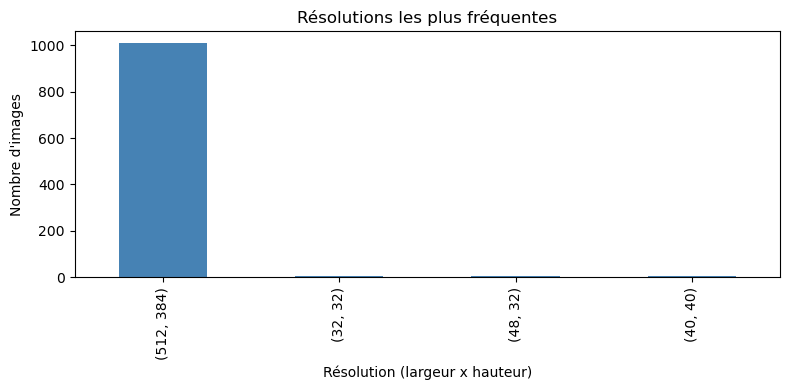

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
res_counts.head(15).plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Résolutions les plus fréquentes")
ax.set_xlabel("Résolution (largeur x hauteur)")
ax.set_ylabel("Nombre d'images")
plt.tight_layout()
plt.show()


### 2) On décide qu'une image doit avoir au minimum 64 × 64 pixels. Identifier toutes les images ne respectant pas cette contrainte.

In [12]:
images_trop_petites = images_ok[(images_ok["largeur"] < 64) | (images_ok["hauteur"] < 64)]
print(f"{len(images_trop_petites)} images plus petites que 64x64 pixels :")
images_trop_petites[["classe", "nom", "largeur", "hauteur"]]


13 images plus petites que 64x64 pixels :


,classe,nom,largeur,hauteur
20,cardboard,cardboard117.jpg,48.0,32.0
77,cardboard,cardboard22.jpg,32.0,32.0
133,cardboard,cardboard70.jpg,40.0,40.0
171,glass,glass100.jpg,40.0,40.0
229,glass,glass15.jpg,48.0,32.0
268,glass,glass21.jpg,32.0,32.0
270,glass,glass23.jpg,32.0,32.0
383,metal,metal121.jpg,48.0,32.0
413,metal,metal2.jpg,32.0,32.0
421,metal,metal26.jpg,40.0,40.0


---
# Partie 5 – Détecter les différents canaux

Nombre d'images par nombre de canaux :
nb_canaux
1.0       2
3.0    1004
4.0      16
Name: count, dtype: int64

Nombre d'images par mode PIL (détail) :
mode
RGB     1004
RGBA      16
P          2
Name: count, dtype: int64


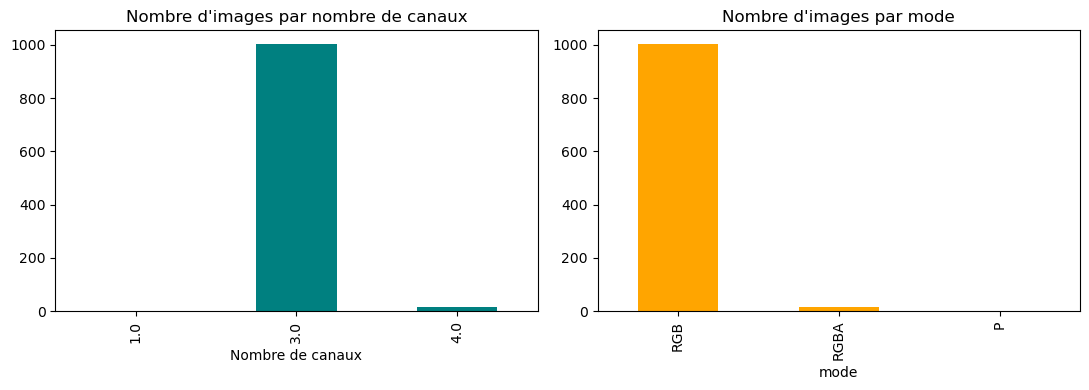

In [13]:
canaux_counts = images_ok["nb_canaux"].value_counts().sort_index()
mode_counts = images_ok["mode"].value_counts()

print("Nombre d'images par nombre de canaux :")
print(canaux_counts)
print("\nNombre d'images par mode PIL (détail) :")
print(mode_counts)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
canaux_counts.plot(kind="bar", ax=axes[0], color="teal")
axes[0].set_title("Nombre d'images par nombre de canaux")
axes[0].set_xlabel("Nombre de canaux")
mode_counts.plot(kind="bar", ax=axes[1], color="orange")
axes[1].set_title("Nombre d'images par mode")
plt.tight_layout()
plt.show()


---
# Partie 6 – Détecter les doublons

In [14]:
def hash_image(path: Path) -> str:
    """Empreinte du contenu pixel de l'image (indépendante du nom de fichier)."""
    with Image.open(path) as im:
        arr = np.array(im.convert("RGB"))
    return hashlib.md5(arr.tobytes()).hexdigest()


images_ok["hash"] = images_ok["chemin"].apply(lambda p: hash_image(Path(p)))

groupes_doublons = images_ok[images_ok.duplicated(subset="hash", keep=False)].sort_values("hash")
n_doublons_a_supprimer = images_ok.duplicated(subset="hash", keep="first").sum()

print(f"{groupes_doublons['hash'].nunique()} groupes de doublons, "
      f"{len(groupes_doublons)} fichiers impliqués, "
      f"{n_doublons_a_supprimer} fichiers à retirer (en gardant 1 exemplaire par groupe).")

groupes_doublons[["classe", "nom", "hash"]]


13 groupes de doublons, 26 fichiers impliqués, 13 fichiers à retirer (en gardant 1 exemplaire par groupe).


,classe,nom,hash
839,plastic,plastic171az.jpg,0ec6c469feec47a0dec34e710f4e2623
838,plastic,plastic171.jpg,0ec6c469feec47a0dec34e710f4e2623
431,metal,metal35.jpg,11759595d22201e53ece4e1b2c70c992
432,metal,metal35rt.jpg,11759595d22201e53ece4e1b2c70c992
757,paper,paperer35.jpg,1879fbdd6bfa6fbb72ead9168debaaa2
686,paper,paper35.jpg,1879fbdd6bfa6fbb72ead9168debaaa2
168,cardboard,image-violet-512x384.gif,22a0ea89c32ebdf57e195d9d0b8da9d6
356,glass,image-violet-512x384.gif,22a0ea89c32ebdf57e195d9d0b8da9d6
466,metal,metal65.jpg,251059c46b37de6c7bd7355599754525
505,metal,metalyu65.jpg,251059c46b37de6c7bd7355599754525


---
# Partie 7 : Détecter les images mal classées

3 groupes de doublons répartis sur plusieurs classes :


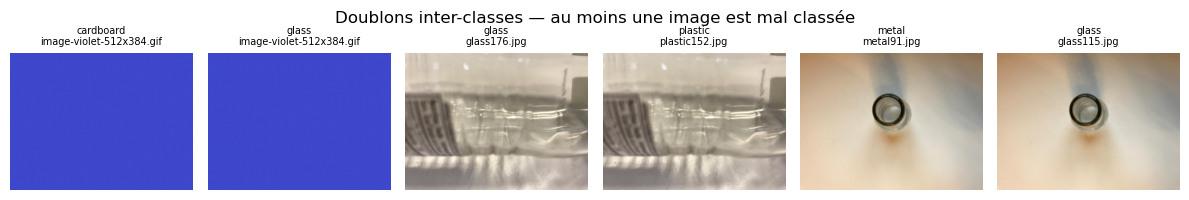

In [20]:
def afficher_grille(df_images: pd.DataFrame, titre: str, n_max: int = 24, n_cols: int = 6):
    df_images = df_images.head(n_max)
    n = len(df_images)
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2))
    axes = np.atleast_2d(axes)
    for ax in axes.flat:
        ax.axis("off")
    for ax, (_, row) in zip(axes.flat, df_images.iterrows()):
        with Image.open(row["chemin"]) as im:
            ax.imshow(im.convert("RGB"))
        ax.set_title(f"{row['classe']}\n{row['nom']}", fontsize=7)
        ax.axis("off")
    fig.suptitle(titre)
    plt.tight_layout()
    plt.show()


# 1) Contrôle ciblé sur les doublons inter-classes détectés en Partie 6
doublons_inter_classes = groupes_doublons.groupby("hash").filter(lambda g: g["classe"].nunique() > 1)
print(f"{doublons_inter_classes['hash'].nunique()} groupes de doublons répartis sur plusieurs classes :")
afficher_grille(doublons_inter_classes, "Doublons inter-classes — au moins une image est mal classée")


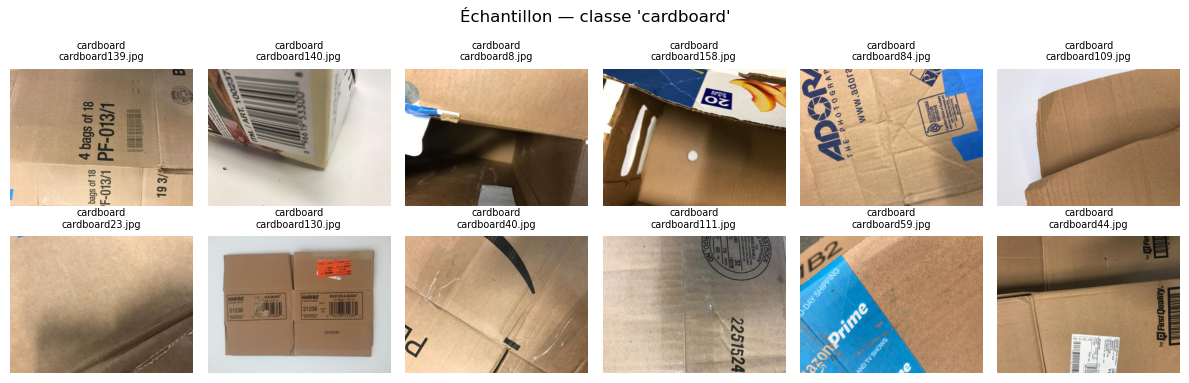

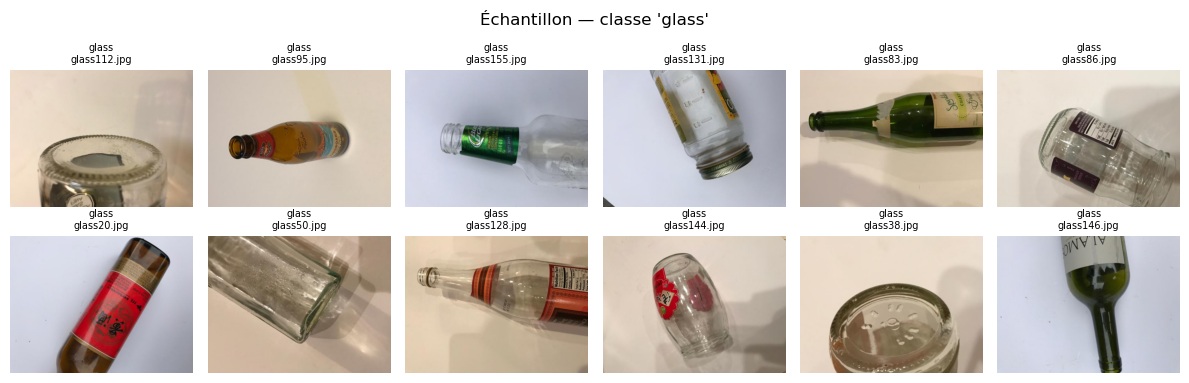

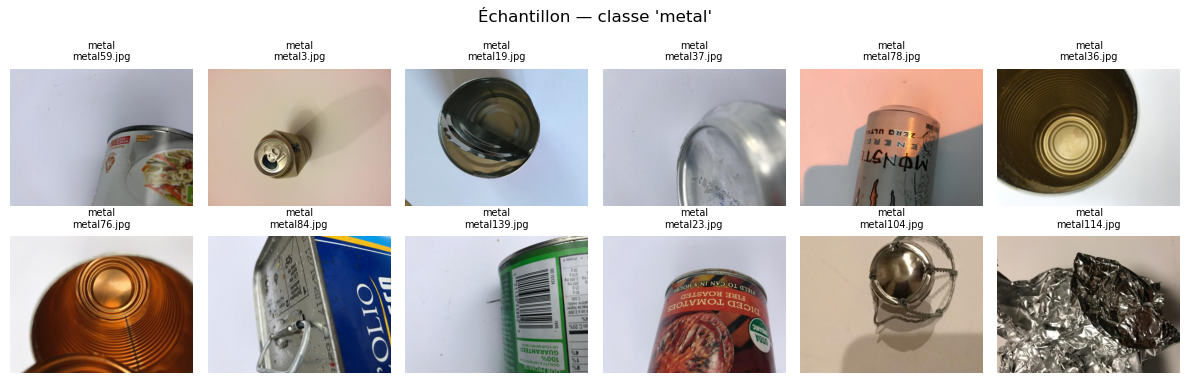

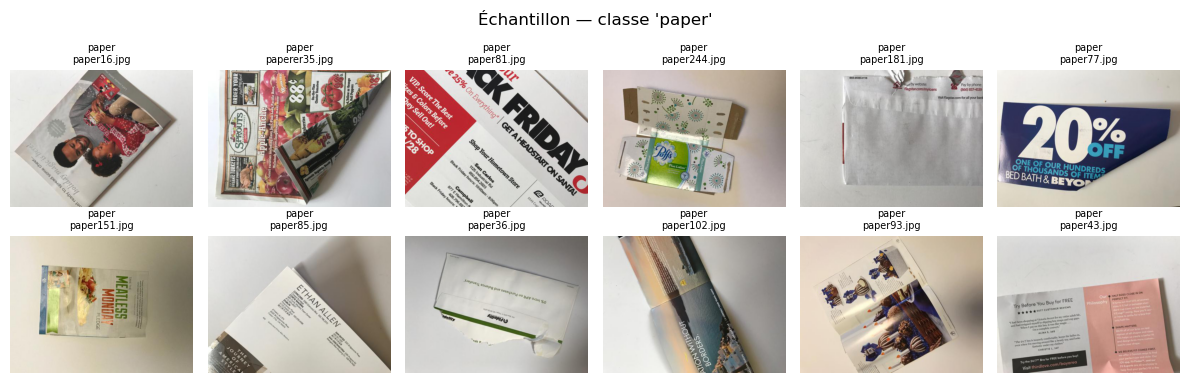

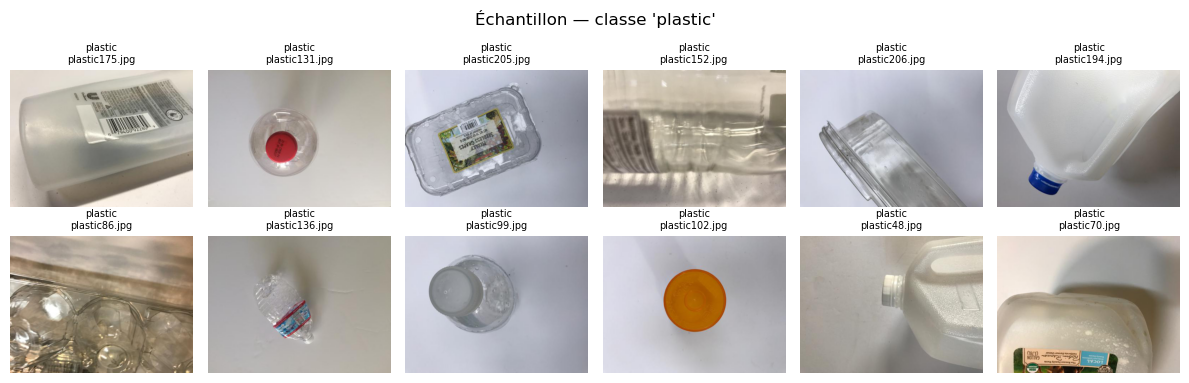

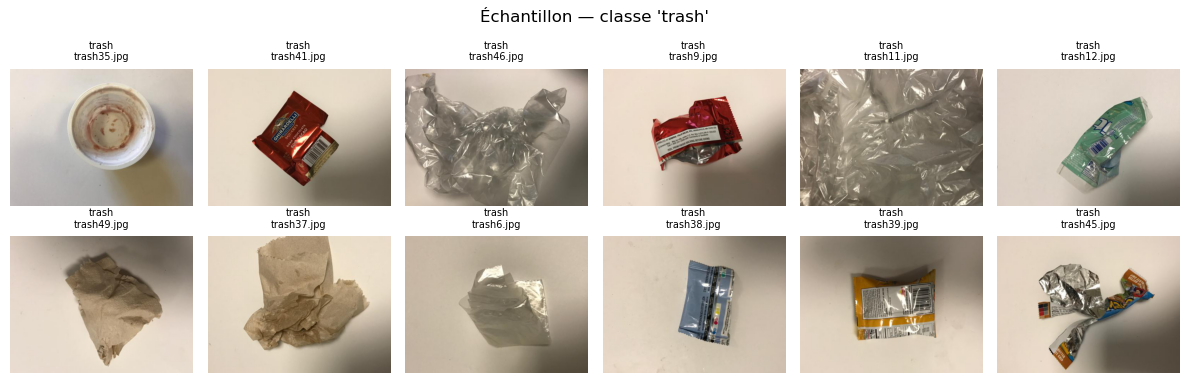

In [16]:
for classe in CLASSES:
    afficher_grille(images_ok[images_ok["classe"] == classe].sample(
        min(12, (images_ok["classe"] == classe).sum()), random_state=1),
        titre=f"Échantillon — classe '{classe}'")


---
# Partie 8 : Analyser le déséquilibre des classes

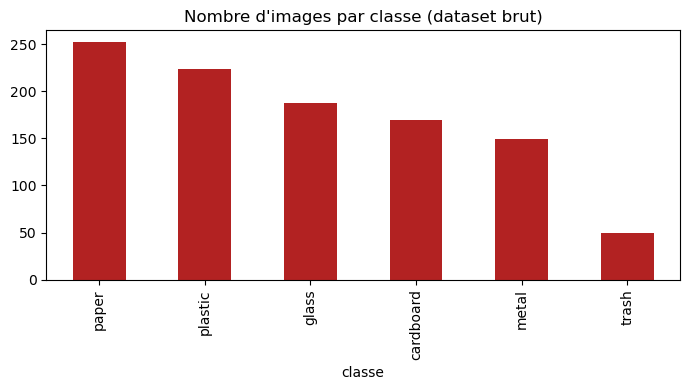

classe
paper        252
plastic      224
glass        188
cardboard    169
metal        149
trash         50
Name: count, dtype: int64

Ratio classe majoritaire / classe minoritaire ≈ 5.0 : 1
Classe minoritaire : 'trash' (50 images) → candidate pour la data augmentation.


In [18]:
classe_counts = audit_df["classe"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
classe_counts.plot(kind="bar", ax=ax, color="firebrick")
ax.set_title("Nombre d'images par classe (dataset brut)")
plt.tight_layout()
plt.show()

print(classe_counts)
ratio = classe_counts.max() / classe_counts.min()
print(f"\nRatio classe majoritaire / classe minoritaire ≈ {ratio:.1f} : 1")
print(f"Classe minoritaire : '{classe_counts.idxmin()}' ({classe_counts.min()} images) "
      f"→ candidate pour la data augmentation.")


---
# Partie 9 : Redimensionnement

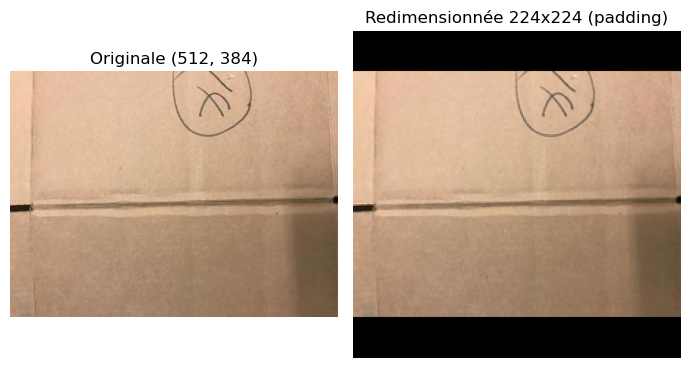

In [19]:
def redimensionner_avec_padding(im: Image.Image, taille: int = 224, couleur_padding=(0, 0, 0)) -> Image.Image:
    """Redimensionne une image à `taille x taille` en conservant le ratio, avec padding."""
    im = im.convert("RGB")
    ratio = min(taille / im.width, taille / im.height)
    nouvelle_taille = (max(1, round(im.width * ratio)), max(1, round(im.height * ratio)))
    im_redim = im.resize(nouvelle_taille, Image.LANCZOS)

    fond = Image.new("RGB", (taille, taille), couleur_padding)
    offset = ((taille - nouvelle_taille[0]) // 2, (taille - nouvelle_taille[1]) // 2)
    fond.paste(im_redim, offset)
    return fond


# Démonstration sur une image
exemple_path = images_ok.iloc[0]["chemin"]
with Image.open(exemple_path) as im:
    im_redim = redimensionner_avec_padding(im)

fig, axes = plt.subplots(1, 2, figsize=(7, 4))
with Image.open(exemple_path) as im_orig:
    axes[0].imshow(im_orig.convert("RGB"))
axes[0].set_title(f"Originale {Image.open(exemple_path).size}")
axes[1].imshow(im_redim)
axes[1].set_title("Redimensionnée 224x224 (padding)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


---
# Partie 10 : Uniformisation des canaux

In [21]:
def construire_dataset_cleaned():
    """Sélectionne les images valides (non corrompues, non vides, taille suffisante, sans
    doublon), les redimensionne/uniformise, et les écrit dans data/cleaned/<classe>/."""
    a_exclure = set(audit_df.loc[audit_df["corrompue"], "chemin"])
    a_exclure |= set(images_vides["chemin"])
    a_exclure |= set(images_trop_petites["chemin"])
    # on ne garde qu'un seul exemplaire par groupe de doublons (le premier alphabétiquement)
    a_exclure |= set(
        images_ok[images_ok.duplicated(subset="hash", keep="first")]["chemin"]
    )

    a_conserver = images_ok[~images_ok["chemin"].isin(a_exclure)].copy()

    for classe in CLASSES:
        (CLEANED_DIR / classe).mkdir(parents=True, exist_ok=True)

    chemins_cleaned = []
    for _, row in a_conserver.iterrows():
        src = Path(row["chemin"])
        dst = CLEANED_DIR / row["classe"] / (src.stem + ".jpg")
        with Image.open(src) as im:
            im_uniforme = redimensionner_avec_padding(im, taille=224)
            im_uniforme.save(dst, format="JPEG", quality=95)
        chemins_cleaned.append({"classe": row["classe"], "chemin": str(dst)})

    return pd.DataFrame(chemins_cleaned), a_conserver, a_exclure


cleaned_df, a_conserver, a_exclure = construire_dataset_cleaned()
print(f"{len(a_exclure)} images exclues (corrompues / vides / trop petites / doublons).")
print(f"{len(cleaned_df)} images écrites dans {CLEANED_DIR} (224x224, RGB).")
cleaned_df["classe"].value_counts()


36 images exclues (corrompues / vides / trop petites / doublons).
996 images écrites dans ..\data\cleaned (224x224, RGB).


classe
paper        245
plastic      218
glass        181
cardboard    164
metal        139
trash         49
Name: count, dtype: int64

---
# Partie 11 : Mise à l'échelle des pixels

In [22]:
def charger_et_normaliser(path: Path, taille: int = 224) -> np.ndarray:
    with Image.open(path) as im:
        arr = np.array(im.convert("RGB").resize((taille, taille)), dtype=np.float32)
    return arr / 255.0


exemple = charger_et_normaliser(Path(cleaned_df.iloc[0]["chemin"]))
print("Shape :", exemple.shape, " dtype :", exemple.dtype)
print("Min pixel :", exemple.min(), " Max pixel :", exemple.max())


Shape : (224, 224, 3)  dtype : float32
Min pixel : 0.0  Max pixel : 0.9843137
